# RF-DETR — Pretrained Model Showcase

## Table of Contents
1. [What is RF-DETR?](#what-is-rf-detr)
2. [Setup](#setup)
3. [Model Variants](#model-variants)
4. [Loading a Pretrained Model](#loading-a-pretrained-model)
5. [Inference on LARS Images](#inference-on-lars-images)
6. [Inference Parameters](#inference-parameters)
7. [Architecture Overview](#architecture-overview)
8. [Fine-Tuning Parameters](#fine-tuning-parameters)
9. [Dataset Preparation for Fine-Tuning](#dataset-preparation-for-fine-tuning)

## What is RF-DETR?

**RF-DETR** (Roboflow Detection Transformer) is a real-time object detection model released by Roboflow in 2025. Key properties:

- **Architecture**: DINOv2 Vision Transformer backbone + deformable-attention decoder
- **End-to-end**: no NMS required — Hungarian matching at train time, top-k selection at inference
- **COCO pretrained**: ships with weights trained on COCO 2017 (80 classes)
- **Two sizes**: `RFDETRBase` (~29 M params) and `RFDETRLarge` (~128 M params)
- **Fine-tunable**: the pretrained weights transfer well to custom datasets with relatively few epochs

> **Note**: The pretrained model outputs COCO categories (e.g. `boat`, `person`). To detect LARS-specific categories (Buoy, Float, etc.) the model must be fine-tuned on our processed dataset.

## Setup

Install the `rfdetr` package (not in `requirements.txt` yet — add it once confirmed):

```bash
python3.11 -m pip install rfdetr supervision
```

`supervision` is a Roboflow utility library used for annotation drawing and is pulled in automatically as a dependency of `rfdetr`, but installing it explicitly ensures the right version.

In [10]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import supervision as sv
from rfdetr import RFDETRBase, RFDETRLarge
from rfdetr.util.coco_classes import COCO_CLASSES

DATA_ROOT = Path("../Data/lars_processed")

## Model Variants

| Variant | Backbone | Params | Default resolution | COCO AP |
|---|---|---|---|---|
| `RFDETRBase` | DINOv2-Small (ViT-S) | ~29 M | 560 px | ~53 |
| `RFDETRLarge` | DINOv2-Base (ViT-B) | ~128 M | 560 px | ~56 |

For the maritime detection task, **`RFDETRBase`** is the practical starting point — it trains faster and the accuracy gap to Large is small for domain-specific fine-tuning.

## Loading a Pretrained Model

Calling the constructor without arguments downloads the COCO-pretrained weights automatically (cached after first download).

In [11]:
# Load RF-DETR Base with COCO pretrained weights
model = RFDETRBase()


[2026-03-27 16:29:14] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-03-27 16:29:15] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


In [12]:
print(dir(model))

['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_has_warned_about_not_being_optimized_for_inference', '_is_optimized_for_inference', '_load_classes', '_model_config_class', '_optimized_batch_size', '_optimized_dtype', '_optimized_has_been_compiled', '_optimized_resolution', '_train_config_class', 'callbacks', 'class_names', 'deploy_to_roboflow', 'export', 'get_model', 'get_model_config', 'get_train_config', 'maybe_download_pretrain_weights', 'means', 'model', 'model_config', 'optimize_for_inference', 'predict', 'remove_optimized_model', 'size', 'stds', 'train']


## Inference on LARS Images

Run the pretrained COCO model on a handful of images from our processed training set.
Since the model was not trained on LARS categories, expect it to fire on `boat` and `person` for some objects while missing domain-specific ones (buoys, floats).

[2026-03-27 16:29:16] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
`use_return_dict` is deprecated! Use `return_dict` instead!


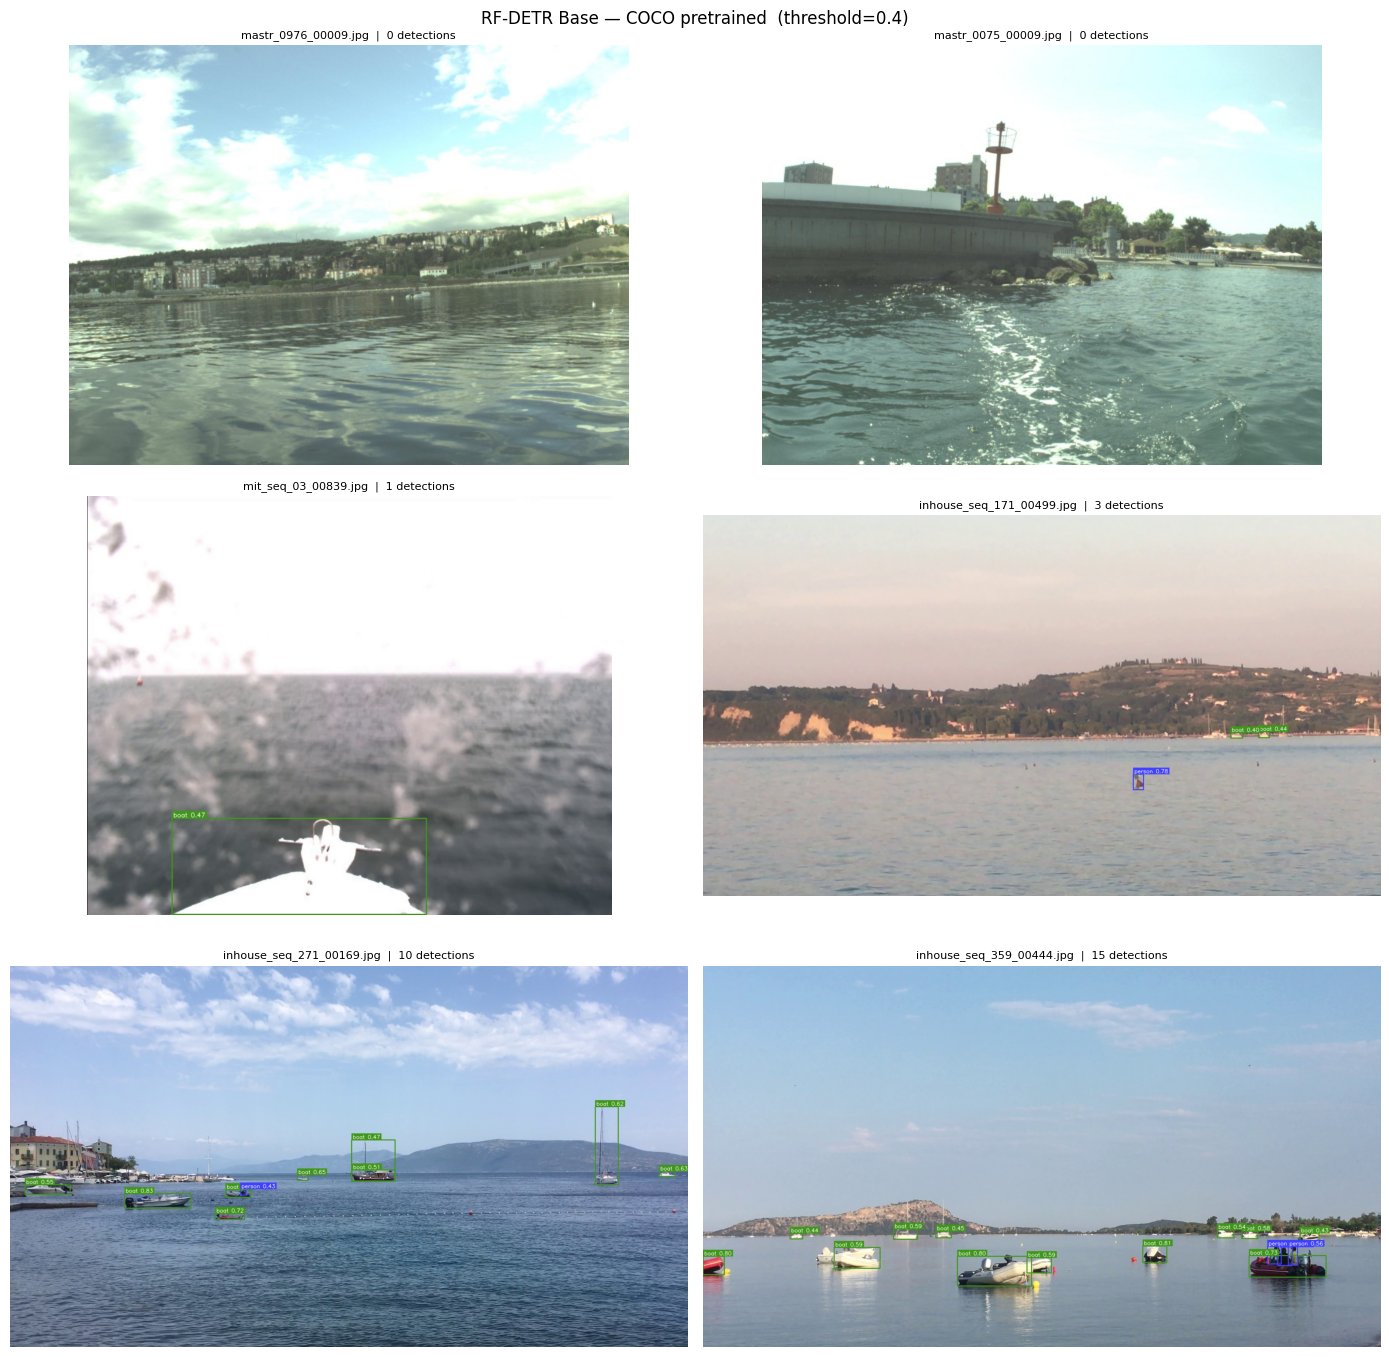

In [13]:
# Sample a few images from the processed train split
img_dir = DATA_ROOT / "train" / "images"
all_imgs = sorted(img_dir.glob("*.jpg"))

random.seed(7)
sample_paths = random.sample(all_imgs, 6)

THRESHOLD = 0.4

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_padding=3)

for ax, img_path in zip(axes.flat, sample_paths):
    pil_img = Image.open(img_path).convert("RGB")
    detections = model.predict(pil_img, threshold=THRESHOLD)

    labels = [
        f"{COCO_CLASSES[cid]} {conf:.2f}"
        for cid, conf in zip(detections.class_id, detections.confidence)
    ]

    img_ann = box_annotator.annotate(np.array(pil_img).copy(), detections)
    img_ann = label_annotator.annotate(img_ann, detections, labels=labels)

    ax.imshow(img_ann)
    ax.set_title(f"{img_path.name}  |  {len(detections)} detections", fontsize=8)
    ax.axis("off")

plt.suptitle(f"RF-DETR Base — COCO pretrained  (threshold={THRESHOLD})", fontsize=12)
plt.tight_layout()
plt.show()

## Inference Parameters

### `threshold` — confidence cutoff
The single most important inference knob. RF-DETR outputs a fixed number of candidate boxes (default 300); `threshold` filters out low-confidence ones.

- **Low threshold** (e.g. 0.2): more detections, more false positives
- **High threshold** (e.g. 0.7): fewer detections, fewer false positives but risks missing objects
- Typical starting point: **0.4 – 0.5**

### `resolution` — input resolution
Passed at model construction time, not at `predict()` time. Must be a **multiple of 56** (ViT patch size × 4).

| Resolution | Speed | Small-object recall |
|---|---|---|
| 448 | fastest | lower |
| 560 | default | good |
| 672 | slower | better |
| 784 | slowest | best |

For maritime scenes with small buoys or distant boats, a higher resolution is likely beneficial.

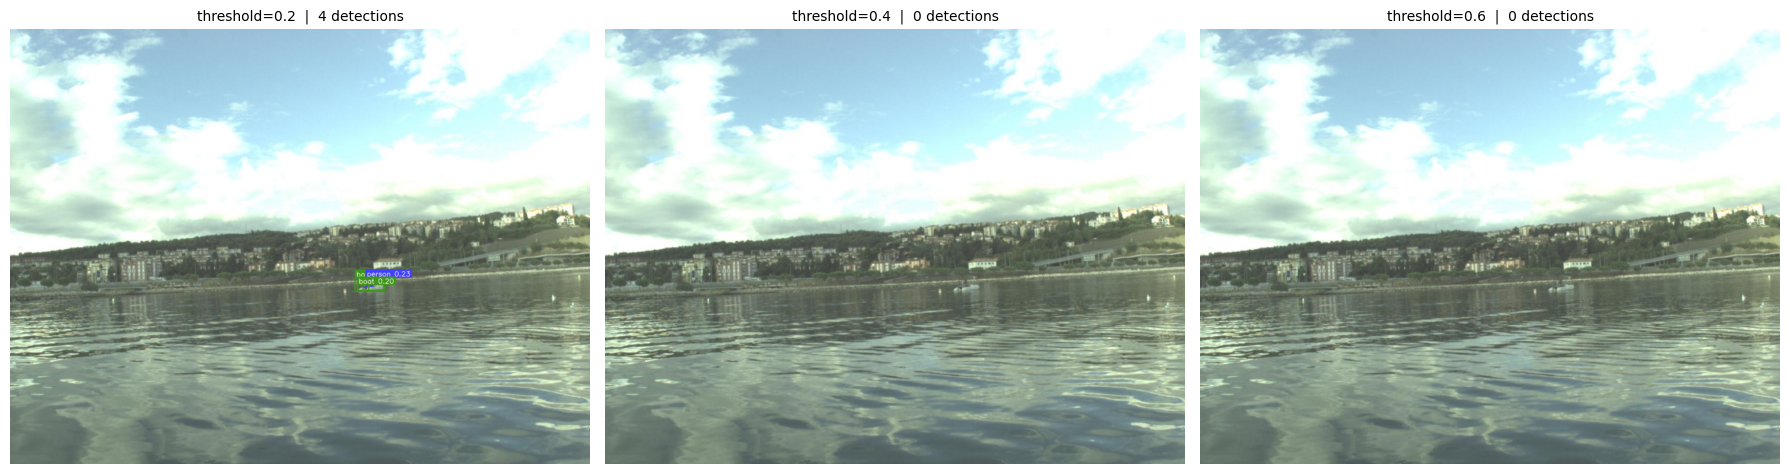

In [14]:
# Visual comparison: effect of confidence threshold on the same image
sample_img = Image.open(sample_paths[0]).convert("RGB")
thresholds = [0.2, 0.4, 0.6]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, thr in zip(axes, thresholds):
    detections = model.predict(sample_img, threshold=thr)
    labels = [
        f"{COCO_CLASSES[cid]} {conf:.2f}"
        for cid, conf in zip(detections.class_id, detections.confidence)
    ]
    img_ann = box_annotator.annotate(np.array(sample_img).copy(), detections)
    img_ann = label_annotator.annotate(img_ann, detections, labels=labels)
    ax.imshow(img_ann)
    ax.set_title(f"threshold={thr}  |  {len(detections)} detections", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

[2026-03-27 16:29:25] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-03-27 16:29:25] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-03-27 16:29:26] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


[2026-03-27 16:29:28] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-03-27 16:29:29] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-03-27 16:29:29] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


[2026-03-27 16:29:30] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-03-27 16:29:31] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-03-27 16:29:31] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


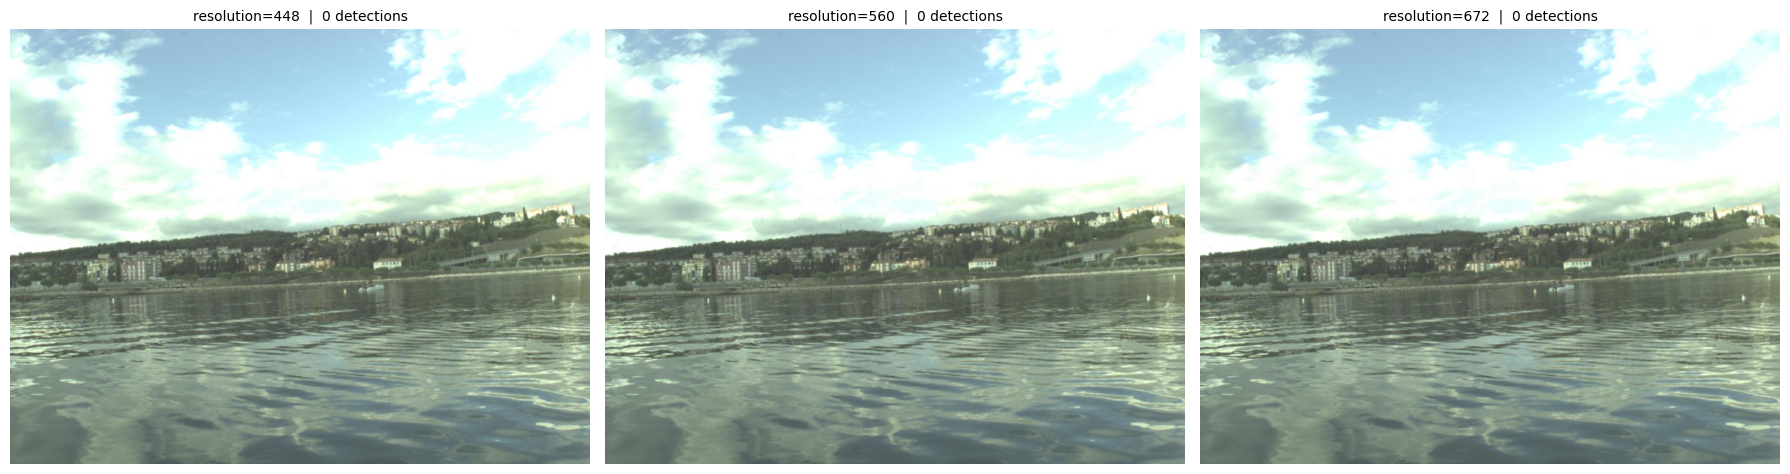

In [15]:
# Visual comparison: effect of input resolution (requires re-instantiating the model)
resolutions = [448, 560, 672]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res in zip(axes, resolutions):
    m = RFDETRBase(resolution=res)
    detections = m.predict(sample_img, threshold=0.4)
    labels = [
        f"{COCO_CLASSES[cid]} {conf:.2f}"
        for cid, conf in zip(detections.class_id, detections.confidence)
    ]
    img_ann = box_annotator.annotate(np.array(sample_img).copy(), detections)
    img_ann = label_annotator.annotate(img_ann, detections, labels=labels)
    ax.imshow(img_ann)
    ax.set_title(f"resolution={res}  |  {len(detections)} detections", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Architecture Overview

```
Input image
    │
    ▼
┌─────────────────────────────┐
│  DINOv2 ViT Backbone        │  ← frozen or low-LR during fine-tuning
│  (ViT-S for Base, ViT-B     │    outputs multi-scale feature maps
│   for Large)                │
└────────────┬────────────────┘
             │ multi-scale features
    ▼
┌─────────────────────────────┐
│  Deformable Attention       │  ← encoder: refines features
│  Encoder                    │
└────────────┬────────────────┘
             │
    ▼
┌─────────────────────────────┐
│  Transformer Decoder        │  ← N learnable object queries attend
│  (object queries)           │    to encoder features
└────────────┬────────────────┘
             │
    ▼
┌─────────────────────────────┐
│  Detection Heads            │  ← per-query: class logits + bbox (cx,cy,w,h)
└─────────────────────────────┘
             │
    ▼
Top-k selection by confidence  ← no NMS; threshold applied here
```

**Training loss** combines:
- Classification: focal loss
- Bounding box: L1 loss + GIoU loss
- Assignment: Hungarian matching (bipartite, one prediction per GT object)

## Fine-Tuning Parameters

These are passed to `model.train()`. The table below lists every major knob with its default value and guidance for our LARS dataset.

| Parameter | Default | Notes |
|---|---|---|
| `dataset_dir` | — | Path to COCO-formatted dataset root (see §9) |
| `epochs` | 50 | 20–50 is usually sufficient for fine-tuning |
| `batch_size` | 4 | Per-GPU batch size; keep low if GPU memory is limited |
| `grad_accum_steps` | 4 | Effective batch = `batch_size × grad_accum_steps` (target ≥16) |
| `lr` | 1e-4 | Learning rate for decoder + heads |
| `lr_encoder` | 1.5e-5 | Learning rate for DINOv2 backbone (10× lower — slow fine-tuning) |
| `resolution` | 560 | Input resolution; must be a multiple of 56 |
| `weight_decay` | 1e-4 | L2 regularisation |
| `grad_clip_max_norm` | 0.1 | Gradient clipping — important for transformer stability |
| `checkpoint_interval` | 10 | Save a checkpoint every N epochs |
| `num_select` | 300 | Number of top queries kept at inference |
| `eos_coeff` | 0.1 | Weight of the "no object" class in the loss — lower = more detections |
| `warmup_epochs` | 0 | LR warmup epochs; setting 1–3 can help stability |

### Recommended starting config for LARS fine-tuning

```python
model.train(
    dataset_dir  = "../Data/lars_processed",
    epochs       = 40,
    batch_size   = 4,
    grad_accum_steps = 4,   # effective batch size = 16
    lr           = 1e-4,
    lr_encoder   = 1e-5,    # keep backbone changes small
    resolution   = 560,
    weight_decay = 1e-4,
    grad_clip_max_norm = 0.1,
    checkpoint_interval = 5,
)
```

In [16]:
# Inspect default training config without launching a run
import inspect
sig = inspect.signature(model.train)
print("model.train() parameters and defaults:\n")
for name, param in sig.parameters.items():
    default = param.default if param.default is not inspect.Parameter.empty else "(required)"
    print(f"  {name:<25} {default}")

model.train() parameters and defaults:

  kwargs                    (required)


## Dataset Preparation for Fine-Tuning

RF-DETR expects the dataset in **COCO format** with a specific folder layout:

```
dataset_dir/
  train/
    images/
    _annotations.coco.json
  valid/
    images/
    _annotations.coco.json
  test/           ← optional
    images/
    _annotations.coco.json
```

Our `datasplit.py` output at `Data/lars_processed/` already has the right COCO JSON structure, but two things need adjusting before fine-tuning:

1. **Rename the validation folder**: `val/` → `valid/`
2. **Rename the annotation file** in each split: `annotations.json` → `_annotations.coco.json`

The cell below performs these renames (safe to re-run — skips if already done).

In [17]:
import shutil

# 1. Rename val → valid
val_path   = DATA_ROOT / "val"
valid_path = DATA_ROOT / "valid"
if val_path.exists() and not valid_path.exists():
    val_path.rename(valid_path)
    print("Renamed: val/ → valid/")
else:
    print("val/ → valid/ already done or val/ missing, skipping")

# 2. Rename annotations.json → _annotations.coco.json in each split
for split in ("train", "valid", "test"):
    src = DATA_ROOT / split / "annotations.json"
    dst = DATA_ROOT / split / "_annotations.coco.json"
    if src.exists() and not dst.exists():
        src.rename(dst)
        print(f"Renamed: {split}/annotations.json → {split}/_annotations.coco.json")
    else:
        print(f"{split}: already renamed or source missing, skipping")

print("\nDataset structure ready for RF-DETR fine-tuning.")

val/ → valid/ already done or val/ missing, skipping
train: already renamed or source missing, skipping
valid: already renamed or source missing, skipping
test: already renamed or source missing, skipping

Dataset structure ready for RF-DETR fine-tuning.
